## B094020012_李圯瀞

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
import torch
import torchvision
print('python', sys.version.split('\n')[0])
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)

python 3.7.15 (default, Oct 12 2022, 19:14:55) 
torch 1.12.1+cu113
torchvision 0.13.1+cu113


In [ ]:
!unzip -qq ./drive/MyDrive/Deep\ Learning/assignment4/deep_fashion.zip

In [ ]:
data_folder = 'deep_fashion'

In [ ]:
import csv
import os
import numpy as np
from PIL import Image
import torch

class FashionData(torch.utils.data.Dataset):
    def __init__(self, csv_file, mode='train', transform=None):
        self.mode = mode # 'train', 'val' or 'test'
        self.data_list = []
        self.labels1 = []
        self.labels2 = []
        self.transform = transform

        with open(f'{data_folder}/{csv_file}', newline='') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                self.data_list.append(f"{row['file_path']}")
                if mode != 'test':
                    self.labels1.append(row['category_label'])
                    attri = np.zeros(15)
                    tmp = row['attribute_label'].split()
                    tmp = [int(i) for i in tmp]
                    for i in tmp:
                      attri[i] = 1
                    self.labels2.append(attri)

    def __getitem__(self, index):
        data = Image.open(self.data_list[index])
        if self.transform is not None:
            data = self.transform(data)
        if self.mode == 'test':
            return data
        label1 = torch.tensor(int(self.labels1[index]))
        label2 = torch.FloatTensor(self.labels2[index])

        return data, label1, label2

    def __len__(self):
        return len(self.data_list)

## Image augmentation

In [ ]:
from torchvision import transforms
import random
import matplotlib.pyplot as plt
import numpy as np
# For TRAIN
########################################################################
#  TODO: use transforms.xxx method to do some data augmentation        #
#  This one is for training, find the composition to get better result #
########################################################################

transforms_train =transforms.Compose([
  transforms.Resize(256),
  transforms.RandomResizedCrop(224),
  transforms.RandomHorizontalFlip(),
  transforms.RandomRotation(15),
  transforms.ToTensor(),
  # transforms.Normalize([0.485, 0.456, 0.406],
  #           [0.229, 0.224, 0.225])
 ])
########################################################################
#                           End of your code                           #
########################################################################

# For VAL, TEST
########################################################################
#  TODO: use transforms.xxx method to do some data augmentation        #
#  This one is for validate and test,                                  #
#  NOTICE some operation we usually not use in this part               #
########################################################################
transforms_test = transforms.Compose([
  transforms.Resize([224, 224]),
  transforms.RandomHorizontalFlip(),
  transforms.ToTensor(),
  # transforms.Normalize([0.485, 0.456, 0.406],
  #           [0.229, 0.224, 0.225])
])
########################################################################
#                           End of your code                           #
########################################################################

In [ ]:
dataset_train = FashionData('train.csv', mode='train', transform=transforms_train)
dataset_val = FashionData('val.csv', mode='val', transform=transforms_test)
dataset_test = FashionData('test.csv', mode='test', transform=transforms_test)

In [ ]:
print("The first image's shape in dataset_train :", dataset_train[0][0].size())
print("There are", len(dataset_train), "images in dataset_train.")

The first image's shape in dataset_train : torch.Size([3, 224, 224])
There are 39092 images in dataset_train.


## Load data

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32
num_workers = 2
train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=num_workers, shuffle=False)
test_loader = DataLoader(dataset_test, batch_size=batch_size, num_workers=num_workers, shuffle=False)

## Build MTL model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        ########################################################################
        #     TODO: use nn.xxx method to generate a CNN model part             #
        ########################################################################

        self.cnn_model = torch.hub.load('pytorch/vision:v0.10.0', 'mobilenet_v2', pretrained=True)
        self.fc1 = nn.Sequential(
            nn.Linear(1000, 10),
            # nn.Dropout(0.3),
            # nn.ReLU(),
            # nn.Linear(100, 10)

        )
        self.fc2 = nn.Sequential(
            nn.Linear(1000, 15),
        )

        ########################################################################
        #                           End of your code                           #
        ########################################################################

    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            x = torch.Tensor(x)
        ########################################################################
        #     TODO: forward your model and get output                          #
        ########################################################################
        x = self.cnn_model(x)
        # print(x.shape)
        x = x.view(x.size(0), -1)
        out1 = self.fc1(x)
        out2 = self.fc2(x)
        out1 = F.log_softmax(out1, dim = 1)
        out2 = torch.sigmoid(out2)
        ########################################################################
        #                           End of your code                           #
        ########################################################################
        return out1, out2

## device setting

In [ ]:

device = torch.device('cuda')
# or
# device = torch.device('cpu')

In [ ]:
model = Net()
model = model.to(device)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/usr/local/lib/python3.7/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Check if model is correct

In [ ]:
import torch
# 32 is batch_size
fake_x = torch.rand(32, 3,112, 112) # generate fake data
fake_x = fake_x.to(device)
pred_cate, pred_attr = model(fake_x) # output of category and attribute
print(pred_cate.shape) # shape should be (batch, 10)
print(pred_attr.shape) # shape should be (batch, 15)

torch.Size([32, 10])
torch.Size([32, 15])


## optimizer and criterion setting

In [ ]:
import torch.nn as nn
import torch.optim as optim
################################################################################
# TODO: Define loss and optmizer functions                                     #
# Try any loss or optimizer function and learning rate to get better result    #
# hint: torch.nn and torch.optim                                               #
################################################################################
criterion1, criterion2 = nn.CrossEntropyLoss(), nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# , betas=(0.9, 0.999)
# optimizer = optim.SGD(model.parameters(), lr=0.01)
################################################################################
#                               End of your code                               #
################################################################################
criterion1 = criterion1.to(device)
criterion2 = criterion2.to(device)

## define train and val

In [ ]:
from sklearn.metrics import f1_score
def train(input_data, model, criterion1, criterion2, optimizer):
    '''
    Argement:
    input_data -- iterable data, typr torch.utils.data.Dataloader is prefer
    model -- nn.Module, model contain forward to predict output
    criterion -- loss function, used to evaluate goodness of model
    optimizer -- optmizer function, method for weight updating
    '''
    model.train()

    pred = torch.tensor([]).to(device)
    true = torch.tensor([]).to(device)
    loss_list = []
    total_count = 0
    acc_count = 0
    for images, labels1, labels2 in input_data:
        images = images.to(device)
        labels1 = labels1.to(device)
        labels2 = labels2.to(device)

        ########################################################################
        # TODO: Forward, backward and optimize                                 #
        # 1. zero the parameter gradients                                      #
        # 2. process input through the network                                 #
        # 3. compute the loss                                                  #
        # 4. propagate gradients back into the network’s parameters            #
        # 5. Update the weights of the network                                 #
        ########################################################################
        optimizer.zero_grad()
        outputs1, outputs2 = model(images)
        outputs2 = outputs2.float()
        labels2 = labels2.float()
        loss = criterion1(outputs1, labels1) + criterion2(outputs2, labels2)

        loss.backward()
        optimizer.step()

        ###################################


        with torch.no_grad():
          _, predicted1 = torch.max(outputs1.data, 1)
          total_count += labels1.size(0)
          acc_count += (predicted1 == labels1).sum().item()
          loss_list.append(loss.item())
          predicted2 = outputs2.clone()
          predicted2[predicted2 >= 0.25] = 1
          predicted2[predicted2 < 0.25] = 0
          pred = torch.cat((pred, predicted2), 0)
          true = torch.cat((true, labels2), 0)

        ########################################################################
        #                           End of your code                           #
        ########################################################################


    # Compute this epoch accuracy and loss

    test_f1 = f1_score(pred.cpu(), true.cpu(), average='samples')
    acc = acc_count / total_count
    loss = sum(loss_list) / len(loss_list)
    return acc, test_f1, loss

In [ ]:
def val(input_data, model, criterion1, criterion2):
    model.eval()

    pred = torch.tensor([]).to(device)
    true = torch.tensor([]).to(device)
    loss_list = []
    total_count = 0
    acc_count = 0
    with torch.no_grad():
        for images, labels1, labels2 in input_data:
            images = images.to(device)
            labels1 = labels1.to(device)
            labels2 = labels2.to(device)

            ####################################################################
            # TODO: Get the predicted result and loss                          #
            # 1. process input through the network                             #
            # 2. compute the loss                                              #
            # 3. get the model predicted result                                #
            # 4. get the counts of correctly classified images                 #
            # 5. save this batch's loss into loss_list                         #
            ####################################################################


            outputs1, outputs2 = model(images)
            outputs2 = outputs2.float()
            labels2 = labels2.float()
            loss = criterion1(outputs1, labels1) + criterion2(outputs2, labels2)


            _, predicted1 = torch.max(outputs1.data, 1)
            total_count += labels1.size(0)
            acc_count += (predicted1 == labels1).sum().item()
            loss_list.append(loss.item())
            predicted2 = outputs2.clone()
            predicted2[predicted2 >= 0.25] = 1
            predicted2[predicted2 < 0.25] = 0

            pred = torch.cat((pred, predicted2), 0)
            true = torch.cat((true, labels2), 0)
            ####################################################################
            #                         End of your code                         #
            ####################################################################
    test_f1 = f1_score(pred.cpu(), true.cpu(), average='samples')
    acc = acc_count / total_count
    loss = sum(loss_list) / len(loss_list)
    return acc, test_f1, loss

# start training

In [ ]:
################################################################################
# You can adjust those hyper parameters to loop for max_epochs times           #
################################################################################
max_epochs = 2
log_interval = 2 # print acc and loss in per log_interval time

train_acc_category_list = []
train_acc_attribute_list = []
train_loss_list = []
val_acc_category_list = []
val_acc_attribute_list = []
val_loss_list = []

for epoch in range(1, max_epochs + 1):
    train_acc_category, train_acc_attribute, train_loss = train(train_loader, model, criterion1, criterion2, optimizer)
    val_acc_category, val_acc_attribute, val_loss = val(val_loader, model, criterion1, criterion2)

    train_acc_category_list.append(train_acc_category)
    train_acc_attribute_list.append(train_acc_attribute)
    train_loss_list.append(train_loss)
    val_acc_category_list.append(val_acc_category)
    val_acc_attribute_list.append(val_acc_attribute)
    val_loss_list.append(val_loss)
    if epoch % log_interval == 0:
        print('=' * 20, 'Epoch', epoch, '=' * 20)
        print('Train category Acc: {:.6f} Train attribute Acc: {:.6f} Train Loss: {:.6f}'.format(train_acc_category, train_acc_attribute, train_loss))
        print('  Val category Acc: {:.6f} Val attribute Acc: {:.6f}  Val Loss: {:.6f}'.format(val_acc_category, val_acc_attribute, val_loss))

################################################################################
#                               End of your code                               #
################################################################################

==================== Epoch 2 ====================
Train category Acc: 0.482733 Train attribute Acc: 0.326406 Train Loss: 1.759868
  Val category Acc: 0.566389 Val attribute Acc: 0.357225  Val Loss: 1.510895


In [ ]:
torch.save(model.state_dict(), 'NAME_OF_THIS_EXPERIMENT.pt')

## Visualize accuracy and loss

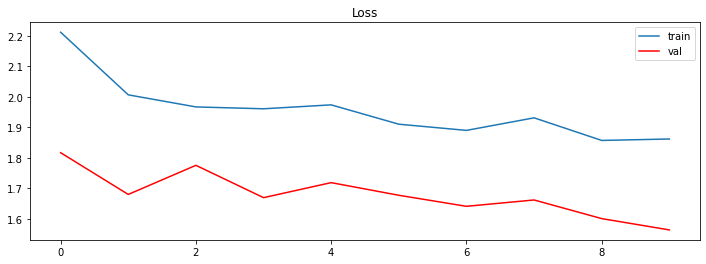

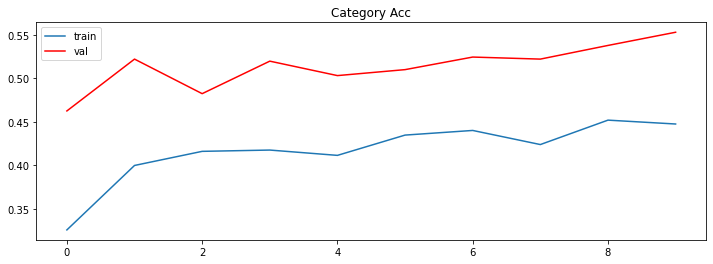

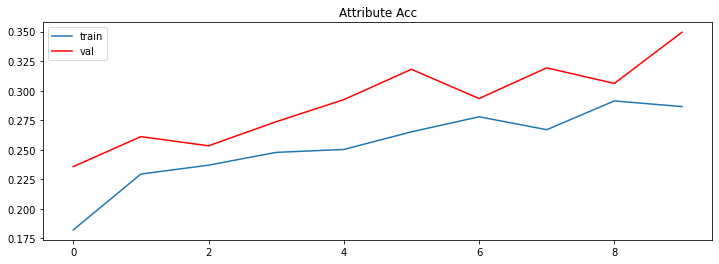

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(range(len(train_loss_list)), train_loss_list)
plt.plot(range(len(val_loss_list)), val_loss_list, c='r')
plt.legend(['train', 'val'])
plt.title('Loss')
plt.show()
plt.figure(figsize=(12, 4))
plt.plot(range(len(train_acc_category_list)), train_acc_category_list)
plt.plot(range(len(val_acc_category_list)), val_acc_category_list, c='r')
plt.legend(['train', 'val'])
plt.title('Category Acc')
plt.show()
plt.figure(figsize=(12, 4))
plt.plot(range(len(train_acc_attribute_list)), train_acc_attribute_list)
plt.plot(range(len(val_acc_attribute_list)), val_acc_attribute_list, c='r')
plt.legend(['train', 'val'])
plt.title('Attribute Acc')
plt.show()

In [ ]:
def predict(input_data, model):
    model.eval()
    output_list1 = []
    output_list2 = []
    with torch.no_grad():
        for images in input_data:
            images = images.to(device)
            outputs1, outputs2 = model(images)
            _, predicted1 = torch.max(outputs1.data, 1)

            outputs2 = outputs2.float()
            predicted2 = outputs2.clone()
            predicted2[predicted2 >= 0.25] = 1
            predicted2[predicted2 < 0.25] = 0

            output_list1.extend(predicted1.to('cpu').numpy().tolist())
            output_list2.extend(predicted2.to('cpu').numpy().tolist())
    return output_list1, output_list2

In [ ]:
idx = 0
output_csv1, output_csv2 = predict(test_loader, model)
with open('result1.csv', 'w', newline='') as csvFile1:
    writer = csv.DictWriter(csvFile1, fieldnames=['file_path', 'category_label'])
    writer.writeheader()
    for result in output_csv1:
        file_path = 'deep_fashion/' +dataset_test.data_list[idx].replace(data_folder + '/', '')
        writer.writerow({'file_path':file_path, 'category_label':result})
        idx += 1
idx = 0
with open('result2.csv', 'w', newline='') as csvFile2:
    writer = csv.DictWriter(csvFile2, fieldnames=['file_path', 'attribute_label'])
    writer.writeheader()
    for result in output_csv2:
        file_path = 'deep_fashion/' + dataset_test.data_list[idx].replace(data_folder + '/', '')
        result = [i for i, x in enumerate(result) if x == 1.0]
        predicted2_ = ''
        for i, x in enumerate(result):
          if i != 0:
            predicted2_ += ' '
          predicted2_ += str(x)
        writer.writerow({'file_path':file_path, 'attribute_label':predicted2_})
        idx += 1